<a href="https://colab.research.google.com/github/insafroumy/Adult-Income-Prediction/blob/main/Adult_Income_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Adult Income Prediction Project
- Auther: Insaf AlRumi

### Imoprts

In [ ]:
!pip install keras_tuner -q

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler , OrdinalEncoder , OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
from sklearn.model_selection import GridSearchCV
from imblearn.over_sampling import SMOTE
from sklearn.inspection import permutation_importance
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.feature_selection import  f_classif , SelectFromModel
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from keras_tuner import HyperParameters as hp
import keras_tuner as kt
from tf_keras.optimizers import Adam , Nadam, RMSprop
import warnings
warnings.filterwarnings('ignore')

### Custom Functions

In [ ]:
def plot_cat(df,col,title):
  fig, ax = plt.subplots(figsize=(8, 6))
  fig.patch.set_facecolor('black')
  fig.patch.set_edgecolor('white')
  fig.patch.set_linewidth(2)
  ax.set_facecolor('black')
  ax.tick_params(colors='white')
  ax.set_xlabel(col ,color='white')
  ax.set_ylabel('Count',color='white')
  for spine in ax.spines.values():
    spine.set_color('white')
  sns.countplot(data=df, x=col, ax=ax, hue= col , palette='Set2')
  ax.set_title(title,color= 'white')
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

In [ ]:
def plot_categorical_vs_target(df, x, y, figsize=(6,4),
                            fillna = True, placeholder = 'MISSING',
                            order = None, target_type='reg'):
  # Make a copy of the dataframe and fillna
  temp_df = df.copy()
  # fillna with placeholder
  if fillna == True:
    temp_df[x] = temp_df[x].fillna(placeholder)
  # or drop nulls prevent unwanted 'nan' group in stripplot
  else:
    temp_df = temp_df.dropna(subset=[x])
  # Create the figure and subplots
  fig, ax = plt.subplots(figsize=figsize)
  # REGRESSION-TARGET PLOT
  if target_type=='reg': #Added if statement here
    # Barplot
    sns.barplot(data=temp_df, x=x, y=y, ax=ax, order=order, alpha=0.6,
                linewidth=1, edgecolor='black', errorbar=None)
    # Boxplot
    sns.stripplot(data=temp_df, x=x, y=y, hue=x, ax=ax,
                  order=order, hue_order=order, legend=False,
                  edgecolor='white', linewidth=0.5,
                  size=3,zorder=0)
  # CLASSIFICATION-TARGET PLOT # This is the new code for the classification task
  elif target_type=='class':
    ax = sns.histplot(data=temp_df, hue=y, x=x, stat='percent',  multiple='fill')
  # Rotate xlabels
  ax.set_xticks(ax.get_xticks()) # Added this to prevent a bug
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
  # Add a title
  ax.set_title(f"{x} vs. {y}")
  fig.tight_layout()
  return fig, ax

In [ ]:
def plot_numeric_vs_target(df, x, y, figsize=(6,4),
                           target_type='reg', estimator='mean',
                           errorbar='ci',sorted=False,ascending=False,
                           **kwargs): # kwargs for sns.regplot

  nulls = df[[x,y]].isna().sum()
  if nulls.sum()>0:
    print(f"- Excluding {nulls.sum()} NaN's")
    # print(nulls)
    temp_df = df.dropna(subset=[x,y,])
  else:
    temp_df = df
  # Create the figure
  fig, ax = plt.subplots(figsize=figsize)

  # REGRESSION-TARGET PLOT
  if 'reg' in target_type:
    # Calculate the correlation
    corr = df[[x,y]].corr().round(2)
    r = corr.loc[x,y]
    # Plot the data
    scatter_kws={'ec':'white','lw':1,'alpha':0.8}
    sns.regplot(data=temp_df, x=x, y=y, ax=ax, scatter_kws=scatter_kws, **kwargs) # Included the new argument within the sns.regplot function
    ## Add the title with the correlation
    ax.set_title(f"{x} vs. {y} (r = {r})")

  # CLASSIFICATION-TARGET PLOT
  elif 'class' in target_type:

    # Sort the groups by median/mean
    if sorted == True:

      if estimator == 'median':
        group_vals = temp_df.groupby(y)[x].median()
      elif estimator =='mean':
        group_vals = temp_df.groupby(y)[x].mean()

      ## Sort values
      group_vals = group_vals.sort_values(ascending=ascending)
      order = group_vals.index

    else:
      # Set order to None if not calcualted
      order = None


    # Left Subplot (barplot)
    sns.barplot(data=temp_df, x=y, y=x, order=order,  estimator=estimator,
                errorbar=errorbar, ax=ax, **kwargs)

    # Add title
    ax.set_title(f"{x} vs. {y}")

    # rotate xaxis labels
    ax.set_xticks(ax.get_xticks())
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


  # Final Adjustments & return
  fig.tight_layout()
  fig.show()
  return fig, ax

In [ ]:
def classification_metrics(y_true, y_pred, label='', output_dict=False, figsize=(8,4), normalize='true', cmap='Blues', colorbar=False):
  # Get the classification report
  report = classification_report(y_true, y_pred)

  ## Print header and report
  header = "-"*70
  print(header, f" Classification Metrics: {label}", header, sep='\n')
  print(report)

  ## CONFUSION MATRICES SUBPLOTS
  fig, axes = plt.subplots(ncols=2, figsize=figsize)

  # create a confusion matrix  of raw counts
  ConfusionMatrixDisplay.from_predictions(y_true, y_pred, normalize=None, cmap='gist_gray', colorbar=colorbar, ax = axes[0],);
  axes[0].set_title("Raw Counts")

  # create a confusion matrix with the test data
  ConfusionMatrixDisplay.from_predictions(y_true, y_pred, normalize=normalize, cmap=cmap, colorbar=colorbar, ax = axes[1]);
  axes[1].set_title("Normalized Confusion Matrix")

  # Adjust layout and show figure
  fig.tight_layout()
  plt.show()

  # Return dictionary of classification_report
  if output_dict==True:
    report_dict = classification_report(y_true, y_pred, output_dict=True)
    return report_dict

In [ ]:
def evaluate_classification(model, X_train, y_train, X_test, y_test, figsize=(6,4), normalize='true', output_dict = False, cmap_train='Blues', cmap_test="Reds",colorbar=False):
  # Get predictions for training data
  y_train_pred = model.predict(X_train)

  # Call the helper function to obtain regression metrics for training data
  results_train = classification_metrics(y_train, y_train_pred, output_dict=True, figsize=figsize, colorbar=colorbar, cmap=cmap_train, label='Training Data')
  print()

  # Get predictions for test data
  y_test_pred = model.predict(X_test)

  # Call the helper function to obtain regression metrics for test data
  results_test = classification_metrics(y_test, y_test_pred, output_dict=True,figsize=figsize, colorbar=colorbar, cmap=cmap_test, label='Test Data' )
  if output_dict == True:
    # Store results in a dataframe if ouput_frame is True
    results_dict = {'train':results_train, 'test': results_test}
    return results_dict

In [ ]:
def plot_importance_color(importances, top_n=None,  figsize=(5,4),
                          color_dict=None):

    # sorting with asc=false for correct order of bars
    if top_n==None:
        ## sort all features and set title
        plot_vals = importances.sort_values()
        title = "All Features - Ranked by Importance"
    else:
        ## sort features and keep top_n and set title
        plot_vals = importances.sort_values().tail(top_n)
        title = f"Top {top_n} Most Important Features"
    ## create plot with colors, if provided
    if color_dict is not None:
        ## Getting color list and saving to plot_kws
        colors = plot_vals.index.map(color_dict)
        ax = plot_vals.plot(kind='barh', figsize=figsize, color=colors)

    else:
        ## create plot without colors, if not provided
        ax = plot_vals.plot(kind='barh', figsize=figsize)

    # set titles and axis labels
    ax.set(xlabel='Importance',
           ylabel='Feature Names',
           title=title)

    ## return ax in case want to continue to update/modify figure
    return ax

### Mount Google Drive

In [ ]:
# Mount google drive
from google.colab import drive
drive.mount('/content/drive')

### Load Data

In [ ]:
fpath = '/content/drive/MyDrive/AXSOSACADEMY/AXSOSACADEMY/05-IntermediateML/Week17/Data/adult.csv'
df = pd.read_csv(fpath)
df.head()

In [ ]:
df.info()

- Our dataset has 15 features and 48842 rows.
- There are varity of data types (6 numeric features and 9 categorical features).

In [ ]:
# check duplicated rows
df.duplicated().sum()

- 52 duplicated rows

In [ ]:
#drop duplicates and then recheck duplicated rows
df= df.drop_duplicates()
df.duplicated().sum()

In [ ]:
#check null values
df.isnull().sum()

- It seems like there are no null values!!

In [ ]:
# check consistencies for categorical features
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
  print(f'{df[col].value_counts()}')

- There is a missing value showns as ?, I have to replace it with NaN

In [ ]:
df[cat_cols] = df[cat_cols].replace('?',np.nan)

- Now I'll recheck the null values

In [ ]:
df.isnull().sum().sum()

- okay, we have 6456 null values in total

In [ ]:
num_cols = df.select_dtypes(include='number').columns
for col in num_cols:
  print(f'{df[col].describe().round(2)}')
  print('-------------------------------------')

- Everything is good.
- Delete education as it indicates to the same thing of what educational-num feature indictes.

In [ ]:
df= df.drop('education', axis=1)

##Exploratory Visualizations

In [ ]:
plot_cat(df,'workclass','Work Class')

- Most people in the dataset work in the Private sector, making it the most influential group for our analysis.
- Other categories like Government and Self-employment have much lower representation.
- Very few individuals are "Without-pay" or "Never-worked," which means the data focuses almost entirely on active workers.

In [ ]:
plot_cat(df,'occupation','Occupation')

- The dataset covers a wide range of jobs, with Prof-specialty, Craft-repair, and Exec-managerial being the most common.
- Unlike the "Work Class" plot, several professional categories have similar counts, showing a more balanced variety of careers
- Certain occupations, such as Armed-Forces and Priv-house-serv, are very rare, which is expected in a general census.

In [ ]:
plot_cat(df,'marital-status','Marital Status')

- The majority of individuals are either Married (civ-spouse) or Never-married, forming the two largest segments of the data.
- There is a noticeable number of Divorced individuals, which is the third most common status
- Groups like Widowed, Separated, and Married-AF-spouse are very small, meaning they have a minor impact on the overall trends.

##Preprocessing data for modeling

- Droping the target and 'fnlwgt' as this feature indicates how many people hold the same information in each row and that will not help in predicting an indiviual adult income.

In [ ]:
# split data into training and testing sets
X = df.drop(columns=['income','fnlwgt'], axis=1)
y = df['income']
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

In [ ]:
# preprocess numeric features
numeric_features = X_train.select_dtypes(include='number').columns
# there is no null values here
#scale the data
scaler= StandardScaler()
num_pipeline = make_pipeline(scaler)
num_tuple = ('numeric',num_pipeline, numeric_features)
num_tuple

In [ ]:
# preprocess categorical features
categorical_features = X_train.select_dtypes(include='object').columns
imputer = SimpleImputer(strategy='most_frequent')
encoder = OneHotEncoder(sparse_output=False,drop='first')
cat_pipeline = make_pipeline(imputer, encoder)
cat_tuple = ('categorical', cat_pipeline, categorical_features)

In [ ]:
# fit the data
preprocessor = ColumnTransformer(transformers=[num_tuple, cat_tuple],verbose_feature_names_out=False)
preprocessor.fit(X_train)

In [ ]:
# transform the data
X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)

## Logistic Regression Model

In [ ]:
# create a baseline model
lr = LogisticRegression(random_state=42)
lr.fit(X_train_processed, y_train)

In [ ]:
# evaluate baseline model
evaluate_classification(lr, X_train_processed, y_train, X_test_processed, y_test)

In [ ]:
y_train.value_counts(normalize=True)

- Imbalanced data

In [ ]:
# oversampling using smote
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_processed, y_train)

In [ ]:
# create another model using resampled data
lr_resampled = LogisticRegression(random_state=42)
lr_resampled.fit(X_train_resampled, y_train_resampled)
#evaluate
evaluate_classification(lr_resampled, X_train_resampled, y_train_resampled, X_test_processed, y_test)

- I will try to tune L1/l2 regularization to get better results.

In [ ]:
# Params compatible with penality='elasticnet'
elasticnet_params = {'solver' : ['saga'],
               'penalty' : ['elasticnet'],
                'l1_ratio': [0, 0.1, 0.2, 0.3, 0.4,
                                                 0.5, 0.6, 0.7, 0.8, 0.9, 1]}
# Params compatible with penality='l2'
l2_params = {'solver': ['lbfgs', 'liblinear', 'newton-cg',
                                            'newton-cholesky', 'sag', 'saga'],
                  'penalty' : ['l2'],
                  'C': [0.0001, 0.001, 0.01, 0.1,
                                            1, 10, 100, 1000] }
# Params compatible with penality='l1'
l1_params = {'solver' : ['liblinear', 'saga'],
               'penalty' : ['l1'],
                'C': [0.0001, 0.001, 0.01, 0.1, 1,
                                          10, 100, 1000]}
# Params with no penality
none_params = {'solver' : ['lbfgs', 'newton-cg',
                                               'newton-cholesky', 'sag', 'saga'],
               'penalty' : [None]}
# Now make a list of the param dictionaries
param_grid = [l2_params, l1_params, elasticnet_params, none_params]

In [ ]:
# Instantiate gridsearch
gs = GridSearchCV(lr_resampled, param_grid, verbose = 5, n_jobs = -1,
                  scoring='recall_macro')
# Fit the gs on the training data only
gs.fit(X_train_resampled, y_train_resampled)
gs.best_params_

In [ ]:
best_lr= gs.best_estimator_
#evaluate
evaluate_classification(best_lr, X_train_resampled, y_train_resampled, X_test_processed, y_test)

- According to model evaluation:
   - It seems that there is no overfitting.
   - Accuracy = 81%
   - The model can detect 80% of people who their income <=50k dollars.
   - The model can detect 84% of people who their income >50k dollars.
   - The model predicts 94% of people in the dataset their income <=50k dollars and that is true.
   -The model predicts 57% of people in the dataset their income >50k dollars and that is true.
   - The model predicts 16% of people their income <=50k dollars while they actually have income >50k dollars.
   - The model predicts 20% of people their income >50k doolars while they actually have income <=50k dollars

In [ ]:
#Get the most important features whose affect heavily on model performance.
r = permutation_importance(best_lr, X_test_processed, y_test, n_repeats=5, random_state=42)
permutation_importance = pd.Series(r.importances_mean, index=preprocessor.get_feature_names_out(),name='permutation importance')
permutation_importance = permutation_importance.sort_values(ascending= False)
permutation_importance

In [ ]:
plot_importance_color(permutation_importance, top_n=10);

- According to this visualization:
  - Being married to civilian is more important than other marital status .Also , it is the most important feature.
  - educational level is the second most important feature.
  - Captial gain is the third most important feature.
  - Not including self employment is more important than other workclass types , and it is the fourth most important feature.
  - Being not in family is more important than other relationship catgories , and it is the fifth most important feature.
  - Being work in executional managerial or in farming fishing is more important than other types in occupation , and it is the sixth most important feature.
  -Being in other service is more important than other types of occupations except executional managerial and in farming fishing, and it is the eighth most important feature.
  - Being black is more important than being white , and it is the tenth most important feature.

In [ ]:
plot_categorical_vs_target(df,x='marital-status',y='income',figsize=(6,4),
                            fillna = False,order = None, target_type='class');

##The Impact of Marital Status on Income Levels

- Individuals who are **Married (civ-spouse)** have the highest probability of being in the high-income bracket (>$50K) compared to any other group. Nearly **45%** of married individuals earn high incomes.
- People who have **Never-married** are significantly more likely to be in the lower-income bracket, with only a very small percentage reaching the high-income mark.
- Marital status is a **strong predictor** of financial stability in this dataset. This suggests that life stage and household structure are closely linked to an individual's earning potential.

In [ ]:
plot_categorical_vs_target(df,x='educational-num',y='income',figsize=(6,4),
                            fillna = False,order = None, target_type='class');

- According to this visualization( the second most important feature):
  - People who have high educational levels like 15 and 16 , most of them have incomes >50k dollars per year.
  - While people in the lowest educational levels , most of them have incomes <=50k dollars per year.
  - The higher your educational level , the gearter your chance to get higher income.

# Part 2

## Clustering


- group similar people into different groups.

In [ ]:
# scale the data
scaled_data= preprocessor.fit_transform(df)

In [ ]:
#Search for the best number of clusters using elbow method and silhouette score
inertia = []
silhouette = []
for i in range(2,11):
  kmeans = KMeans(n_clusters=i, random_state=42)
  kmeans.fit(scaled_data)
  inertia.append(kmeans.inertia_)
  silhouette.append(silhouette_score(scaled_data, kmeans.labels_))
fig,axes = plt.subplots(1,2,figsize=(10,5))
axes[0].plot(range(2,11),inertia)
axes[0].set_xlabel('Number of Clusters')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method')
axes[1].plot(range(2,11),silhouette)
axes[1].set_xlabel('Number of Clusters')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score')

- I think that using 5 clusters will be the right decision , as inertia at 5 clusters is less than inertia at 2 or 3 or 4 clusters. Also , silouette score is high comparing with it at 4 clusters.

In [ ]:
kmeans = KMeans(n_clusters=5,n_init='auto' ,random_state=42)
kmeans.fit(scaled_data)

In [ ]:
# add cluster labels to the scaled data
df['cluster']= kmeans.labels_
display(df.head())

In [ ]:
# group by clusters
num_cols = df.select_dtypes(include='number').columns.tolist()
cat_cols = df.select_dtypes(include='object').columns.tolist()

# Create a dictionary of aggregation functions for each column
agg_dict = {col: 'mean' for col in num_cols if col != 'cluster'} # Exclude cluster from mean calculation
agg_dict.update({col: lambda x: x.mode()[0] if not x.mode().empty else None for col in cat_cols})

df_clustered = df.groupby('cluster').agg(agg_dict)
display(df_clustered.head())

- Can`t visualize clusters as we have 5 clusters. But we can create pcs to visualize them.

In [ ]:
pcs = PCA(n_components=3)
pcs.fit(scaled_data)
pcs_data = pcs.transform(scaled_data)

In [ ]:
# visualize
fig = px.scatter_3d(pcs_data, x=0, y=1, z=2, color=kmeans.labels_)
fig.show()

- cluster 0 is colored by blue.
- cluster 1 is colored by purple.
- cluster 2 is colored by pink.
- cluster 3 is colored by orange .
- cluster 4 is colored by yellow.

##Instantiate Principle components

- It is a techniqe to of feature extraction, as we have 13 features in our training set , we can minimize it into 2 or 3 components for easier visualization , better model performance and more speed.

In [ ]:
# instantiate pcs
pca= PCA(n_components=3)
# fit on training set
pca.fit(X_train_resampled)

In [ ]:
# transform on training and testing sets
X_train_pcs = pca.transform(X_train_resampled)
X_test_pcs = pca.transform(X_test_processed)

In [ ]:
# add pcs to the original dataframe
df_pcs = pd.DataFrame(X_train_pcs, columns=['PC1','PC2','PC3'])
df_pcs['target'] = y_train_resampled
df_with_pcs = pd.concat([df, df_pcs], axis=1)
df_with_pcs.head()

In [ ]:
# visualize pcs
fig = px.scatter_3d(df_pcs , x='PC1', y='PC2', z='PC3',color='target')
fig.show()

In [ ]:
# try to instantiate model using pcs
lr_pcs = LogisticRegression(random_state=42)
lr_pcs.fit(X_train_pcs, y_train_resampled)

In [ ]:
# evaluate
evaluate_classification(lr_pcs, X_train_pcs, y_train_resampled, X_test_pcs, y_test)

- It seems that results were good when we used the original features.

## Trying some methods of feature engineering

In [ ]:
X_train_resampled_df = pd.DataFrame(X_train_resampled, columns=preprocessor.get_feature_names_out())
corr = X_train_resampled_df.corr()
ax= sns.heatmap(corr,cmap='coolwarm')
ax.figure.set_size_inches(20,20)

- It seems that there is no multicolinearity(A lot of reds).
- Also , I don`t notice any constant or quasi-constant features in this dataset.
- A well as , we don`t have to reduce so many features as we have 13 features to fit which is not very large.

- I will try using embedded method : using logistic regression coefficients

In [ ]:
# Instantiate a lostistic regression model
log_reg = LogisticRegression(C=1e12)
# Define the selector object using the model. Use default threshold (mean)
selector = SelectFromModel(log_reg)
# Fit the selector on the training data
selector.fit(X_train_resampled ,y_train_resampled)
selector

In [ ]:
# Obtain threshold used
selector.threshold_

In [ ]:
selector.estimator_.coef_.shape

In [ ]:
flattened = selector.estimator_.coef_.flatten()
flattened.shape

In [ ]:
coeffs = pd.Series(flattened, index=preprocessor.get_feature_names_out())
coeffs

In [ ]:
above_threshold = selector.get_support()
coeffs[above_threshold]

In [ ]:
above_threshold = selector.get_support()
# Only include the features that are above the threshold in X train and X test
X_train_sel = X_train_resampled_df.loc[:,above_threshold]
X_test_processed_df = pd.DataFrame(X_test_processed, columns=preprocessor.get_feature_names_out())
X_test_sel = X_test_processed_df.loc[:,above_threshold]
X_train_sel.shape

In [ ]:
# instantiate a new log_reg
log_reg = LogisticRegression(random_state=42)
# fit the model
log_reg.fit(X_train_sel, y_train_resampled)

In [ ]:
# evaluate
evaluate_classification(log_reg, X_train_sel, y_train_resampled, X_test_sel, y_test)

- According to model evaluation:
It seems that there is no overfitting.
 - Accuracy = 79%
 - The model can detect 77% of people who their income <=50k dollars.
 - The model can detect 85% of people who their income >50k dollars.
 - The model predicts 94% of people in the dataset their income <=50k dollars and that`s true.
 - The model predicts 54% of people in the dataset their income >50k dollars and that`s true.
 - The model predicts 15% of people their income <=50k dollars while they actually have income >50k dollars.
 - The model predicts 23% of people their income >50k doolars while they actually have income <=50k dollars.

- Feature selection using logistic regression coefficients does`nt enhance the model performance as:
  -  the accuracy decreased by 2% .
  - detecting people who their incomes <=50k dollars decreased by 3%.
  - detecting people who their incomes >50k dollars increased by 1% .
  - Percision of class ">50k" decreased by 3%.
  - False positive erros increased by 1%.
  - False negative erros increased by 3% .

##Neural Network

In [ ]:
# get the number of features as the input for the input layer
input_shape = X_train_resampled.shape[1]
input_shape

So, 81 features will be entered into input layer.

In [ ]:
# choose the type of the model -> I will choose sequential model where layers ran sequentially
model = Sequential()

In [ ]:
# the first hidden layer
model.add(Dense(units= 81, activation='relu', input_shape=(input_shape,)))

In [ ]:
# output layer (task is  binary classification so , I need one unit and the activation function will be sigmoid)
model.add(Dense(units=1, activation='sigmoid'))

In [ ]:
# complie the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy', tf.keras.metrics.Precision(name= 'precision'), tf.keras.metrics.Recall(name = 'recall')])

In [ ]:
# One-hot encode the target variable
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train_resampled)

In [ ]:
# fit the model
history = model.fit(X_train_resampled, y_train_encoded, epochs=50, batch_size=32, validation_split=0.2, callbacks=[EarlyStopping(monitor='val_accuracy', patience=5)])

In [ ]:
# Custom function for plotting each metric
def plot_history(history, figsize=(6,12), marker='o'):

    # Get list of metrics from history
    metrics = [c for c in history.history if not c.startswith('val_')]

    ## Separate row for each metric
    fig, axes = plt.subplots(nrows=len(metrics),figsize=figsize)

    # For each metric
    for i, metric_name in enumerate(metrics):

        # Get the axis for the current metric
        ax = axes[i]

        # Get metric from history.history
        metric_values = history.history[metric_name]
        # Get epochs from history
        epochs = history.epoch

        # Plot the training metric
        ax.plot(epochs, metric_values, label=metric_name, marker=marker)

        ## Check if val_{metric} exists. if so, plot:
        val_metric_name = f"val_{metric_name}"
        if val_metric_name in history.history:
            # Get validation values and plot
            metric_values = history.history[val_metric_name]
            ax.plot(epochs,metric_values,label=val_metric_name, marker=marker)

        # Final subplot adjustments
        ax.legend()
        ax.set_title(metric_name)
    fig.tight_layout()

    return fig, axes

In [ ]:
plot_history(history);

- It seems that the model is overfitting , as according to the plots above:
   - Loss in validation set is higher than loss in training set and there is a big gap between them.
   - Accuracy in validation set is lower than accuracy in training set and there is a gap between them.


In [ ]:
# evaluate on unseen data
y_test_encoded = le.transform(y_test)
model.evaluate(X_test_processed, y_test_encoded, return_dict=True)

In [ ]:
# evaluate using classification metrics
print('Training data')
train_preds= model.predict(X_train_resampled)
print(classification_report(y_train_encoded, train_preds.round()))
ConfusionMatrixDisplay.from_predictions(y_train_encoded, train_preds.round());

In [ ]:
# evaluate testing set using classification metrics
print('Testing data')
test_preds= model.predict(X_test_processed)
print(classification_report(y_test_encoded, test_preds.round()))
ConfusionMatrixDisplay.from_predictions(y_test_encoded, test_preds.round());

**Try to reduce overfitting by tuning hyperparameters like : number of
neurons , dropout rate , optimizer choice and learning rate.**

##Tuning 3 parameters to get the best neural network

In [ ]:
# Build and Compile Model within a function to try different optimizers, units,learning rates and dropout values
def build_model(hp):
    # Instantiate Model
    model = Sequential()
    # First hidden layer
    # Try different values for units
    model.add(Dense(units=hp.Int('units', min_value=31, max_value=81, step=10),input_dim = input_shape, activation='relu'))
    # Try different values for dropout rate
    model.add(Dropout(hp.Float(name="dropout_value", min_value=0.0, max_value=0.5, step=0.1)))
    model.add(Dense(1, activation = 'sigmoid'))

    # Try different optimizers and learning rates by passing their string names
    optimizer_choice = hp.Choice('optimizer', values=['adam', 'nadam', 'rmsprop'])
    learning_rate = hp.Choice('learning_rate', values=[.1, .01, .001])
    if optimizer_choice == 'adam':
        optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    elif optimizer_choice == 'nadam':
        optimizer = tf.keras.optimizers.Nadam(learning_rate=learning_rate)
    elif optimizer_choice == 'rmsprop':
        optimizer = tf.keras.optimizers.RMSprop(learning_rate=learning_rate)

    # Compile Model with the chosen optimizer and learning rate
    model.compile(optimizer=optimizer,
                  loss='binary_crossentropy', # Use binary_crossentropy for binary classification
                  metrics=['accuracy',tf.keras.metrics.Recall(name='recall'),tf.keras.metrics.Precision(name='precision')])
    return model

In [ ]:
# Make a folder to store results of hyperparameter tuning
import os
folder = 'KerasTuner/'
os.makedirs(folder, exist_ok=True)

In [ ]:
# Define tuner object
tuner = kt.Hyperband(build_model, objective='val_accuracy', max_epochs=100, directory=folder, overwrite = False, seed = 42 , project_name='Adult_incomes_tuning')

In [ ]:
# Run the tuner
epochs = 100
tuner.search(X_train_resampled, y_train_encoded,  epochs=epochs, validation_split= .2, callbacks = [EarlyStopping(monitor='val_accuracy', patience=5)])

Trial 254 Complete [00h 00m 39s]
val_accuracy: 0.8852473497390747

Best val_accuracy So Far: 0.99973064661026
Total elapsed time: 01h 39m 24s


In [ ]:
# Obtain best hyperparameter values
best_hps=tuner.get_best_hyperparameters()[0]
best_hps.values

{'units': 71,
 'dropout_value': 0.0,
 'optimizer': 'nadam',
 'learning_rate': 0.1,
 'tuner/epochs': 4,
 'tuner/initial_epoch': 2,
 'tuner/bracket': 4,
 'tuner/round': 1,
 'tuner/trial_id': '0011'}

In [ ]:
# Obtain best model
best_model = tuner.get_best_models()[0]
best_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 71)             │         5,822 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 71)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            72 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,894 (23.02 KB)

 Trainable params: 5,894 (23.02 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# evaluate on testing set
best_model.evaluate(X_test_processed, y_test_encoded, return_dict=True)

382/382 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.3174 - loss: 1.4682 - precision: 0.2600 - recall: 0.9973


{'accuracy': 0.3174290955066681,
 'loss': 1.4682461023330688,
 'precision': 0.2599644064903259,
 'recall': 0.9972696304321289}

In [ ]:
# Inspect results in more detail
tuner.results_summary(5)

Results summary
Results in KerasTuner/Adult_incomes_tuning
Showing 5 best trials
Objective(name="val_accuracy", direction="max")

Trial 0127 summary
Hyperparameters:
units: 71
dropout_value: 0.0
optimizer: nadam
learning_rate: 0.1
tuner/epochs: 4
tuner/initial_epoch: 2
tuner/bracket: 4
tuner/round: 1
tuner/trial_id: 0011
Score: 0.99973064661026

Trial 0221 summary
Hyperparameters:
units: 41
dropout_value: 0.1
optimizer: nadam
learning_rate: 0.1
tuner/epochs: 12
tuner/initial_epoch: 0
tuner/bracket: 2
tuner/round: 0
Score: 0.9864416122436523

Trial 0134 summary
Hyperparameters:
units: 81
dropout_value: 0.2
optimizer: rmsprop
learning_rate: 0.1
tuner/epochs: 12
tuner/initial_epoch: 4
tuner/bracket: 4
tuner/round: 2
tuner/trial_id: 0101
Score: 0.9841070175170898

Trial 0200 summary
Hyperparameters:
units: 61
dropout_value: 0.0
optimizer: rmsprop
learning_rate: 0.1
tuner/epochs: 12
tuner/initial_epoch: 4
tuner/bracket: 3
tuner/round: 1
tuner/trial_id: 0156
Score: 0.9807847738265991

Trial 

Training data
1741/1741 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
              precision    recall  f1-score   support

           0       0.99      0.10      0.19     27841
           1       0.53      1.00      0.69     27841

    accuracy                           0.55     55682
   macro avg       0.76      0.55      0.44     55682
weighted avg       0.76      0.55      0.44     55682



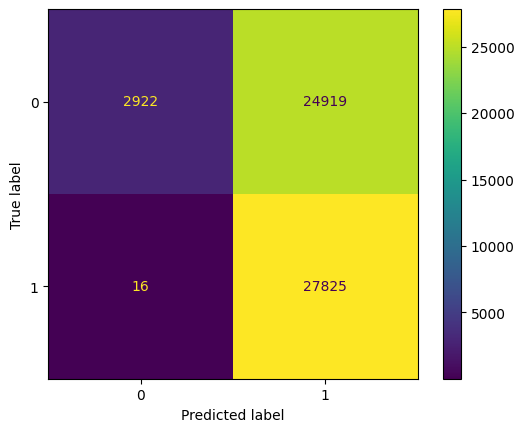

In [ ]:
# evaluate using classification metrics
print('Training data')
train_preds= best_model.predict(X_train_resampled)
print(classification_report(y_train_encoded, train_preds.round()))
ConfusionMatrixDisplay.from_predictions(y_train_encoded, train_preds.round());

Testing data
382/382 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
              precision    recall  f1-score   support

           0       0.99      0.10      0.19      9268
           1       0.26      1.00      0.41      2930

    accuracy                           0.32     12198
   macro avg       0.63      0.55      0.30     12198
weighted avg       0.82      0.32      0.24     12198



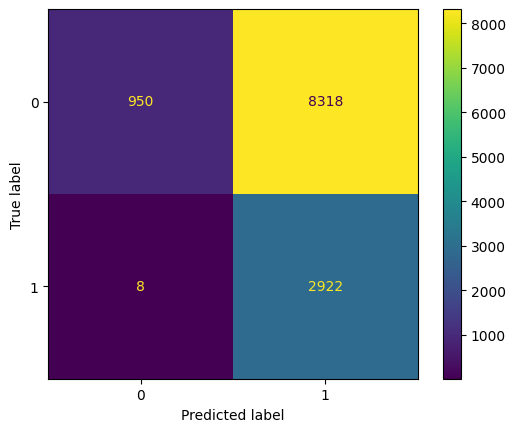

In [ ]:
# evaluate testing set using classification metrics
print('Testing data')
test_preds= best_model.predict(X_test_processed)
print(classification_report(y_test_encoded, test_preds.round()))
ConfusionMatrixDisplay.from_predictions(y_test_encoded, test_preds.round());

- After tuning , it seems that the baseline model is much better than the recent one.